--- PARTE 1: SIMULACIÓN POISSON ---


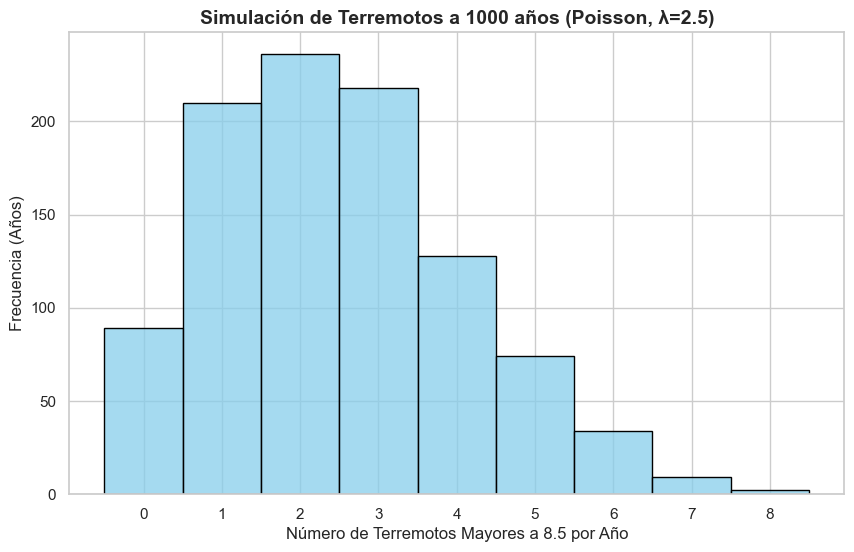


--- PARTE 2: PRUEBA ANOVA ---
Grupo Alto (>5 visitas/mes): n=1170 clientes, Media de compras web = 3.92
Grupo Bajo (<=5 visitas/mes): n=1070 clientes, Media de compras web = 4.26

--- RESULTADOS ANOVA ---
Estadístico F: 8.5037
P-valor: 3.5796e-03 (Equivalente a 0.0036)

CONCLUSIÓN: Rechazamos la Hipótesis Nula.
Sí existe una diferencia estadísticamente significativa en el número de compras web entre ambos grupos de clientes.


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual de "Grado Ejecutivo"
sns.set_theme(style="whitegrid", palette="muted")

# ==============================================================================
# PARTE 1: SIMULACIÓN DE DISTRIBUCIÓN POISSON (Terremotos > 8.5 Richter)
# ==============================================================================
print("--- PARTE 1: SIMULACIÓN POISSON ---")
# Parámetros dados por la rúbrica
lam = 2.5    # Promedio de terremotos por año
size = 1000  # Años simulados

# Fijamos una semilla para que los resultados sean reproducibles
np.random.seed(42)

# Simulación
poisson_sim = np.random.poisson(lam, size)

# Visualización
plt.figure(figsize=(10, 6))
sns.histplot(poisson_sim, bins=range(0, max(poisson_sim)+2), discrete=True, color="skyblue", edgecolor="black")
plt.title("Simulación de Terremotos a 1000 años (Poisson, λ=2.5)", fontsize=14, fontweight='bold')
plt.xlabel("Número de Terremotos Mayores a 8.5 por Año", fontsize=12)
plt.ylabel("Frecuencia (Años)", fontsize=12)
plt.xticks(range(0, max(poisson_sim)+1))
plt.show()

# ==============================================================================
# PARTE 2: PRUEBA DE HIPÓTESIS (ANOVA) - VISITAS VS COMPRAS WEB
# ==============================================================================
print("\n--- PARTE 2: PRUEBA ANOVA ---")

# 1. Carga de datos (Usamos coma como separador)
ruta = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 6 Estadística\MOD 2 Estadística Inferencial\Práctica\marketing_campaign.csv"
df = pd.read_csv(ruta, sep=',')

# 2. Limpieza preventiva
df_clean = df.dropna(subset=['NumWebPurchases', 'NumWebVisitsMonth'])

# 3. Agrupación (Visitas altas > 5, Visitas bajas <= 5)
high_visits = df_clean[df_clean['NumWebVisitsMonth'] > 5]['NumWebPurchases']
low_visits = df_clean[df_clean['NumWebVisitsMonth'] <= 5]['NumWebPurchases']

# Imprimimos contexto
print(f"Grupo Alto (>5 visitas/mes): n={len(high_visits)} clientes, Media de compras web = {high_visits.mean():.2f}")
print(f"Grupo Bajo (<=5 visitas/mes): n={len(low_visits)} clientes, Media de compras web = {low_visits.mean():.2f}")

# 4. Prueba ANOVA (F de Fisher) usando scipy.stats
f_stat, p_value = stats.f_oneway(high_visits, low_visits)

print("\n--- RESULTADOS ANOVA ---")
print(f"Estadístico F: {f_stat:.4f}")
print(f"P-valor: {p_value:.4e} (Equivalente a {p_value:.4f})")

# 5. Conclusión automatizada
alpha = 0.05
if p_value < alpha:
    print("\nCONCLUSIÓN: Rechazamos la Hipótesis Nula.")
    print("Sí existe una diferencia estadísticamente significativa en el número de compras web entre ambos grupos de clientes.")
else:
    print("\nCONCLUSIÓN: No rechazamos la Hipótesis Nula.")
    print("No existe una diferencia estadísticamente significativa en el número de compras web entre los grupos.")